In [127]:
#importy
import requests
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [128]:
#Część 1: pobranie z źródła danych z obsługą wyjątków
url = "https://restcountries.com/v4/all?fields=name,capital,currencies,region,subregion,population,area"

try:
    response = requests.get(url, timeout=10)  # timeout = max czas oczekiwania
    response.raise_for_status()  # wyrzuci wyjątek jeśli status != 200
    data = response.json()
    print(f"Pobrano {len(data)} rekordów")
except requests.exceptions.ConnectionError:
    print("Błąd połączenia — sprawdź internet")
except requests.exceptions.Timeout:
    print("Przekroczono czas oczekiwania")
except requests.exceptions.HTTPError as e:
    print(f"Błąd HTTP: {e}")


#pobranie pól z response i budowanie DF    
rows = []

for country in data: 
    row = {
        "nazwa": country.get("name", {}).get("common"),
        "stolica": (country.get("capital") or [None])[0],
        "region": country.get("region"),
        "subregion": country.get("subregion"),
        "populacja": country.get("population"),
        "powierzchnia": country.get("area"),
        "waluta": (country.get("currencies") or [{}])[0].get("code")
    }
    rows.append(row)

df = pd.DataFrame(rows)

Pobrano 250 rekordów


In [129]:
#wyswietlenie head
df.head()

,nazwa,stolica,region,subregion,populacja,powierzchnia,waluta
0,Turkmenistan,Ashgabat,Asia,Central Asia,6117933,488100.0,TMT
1,Iraq,Baghdad,Asia,Western Asia,38274618,438317.0,IQD
2,Barbados,Bridgetown,Americas,Caribbean,281998,439.0,BBD
3,Niue,Alofi,Oceania,Polynesia,1821,260.0,NZD
4,Trinidad and Tobago,Port of Spain,Americas,Caribbean,1512779,5130.0,TTD


In [130]:
#wyswietlenie shape
df.shape

(250, 7)

In [131]:
#wyswietlenie dtypes
df.dtypes

nazwa               str
stolica             str
region              str
subregion           str
populacja         int64
powierzchnia    float64
waluta              str
dtype: object

In [132]:
#Część 2 — Zapis do bazy SQLite
conn = sqlite3.connect("kraje_swiata.db")

df.to_sql("kraje", conn, if_exists="replace", index=False)
print("Dane zapisane w bazie 'kraje_swiata.db'")

Dane zapisane w bazie 'kraje_swiata.db'


In [133]:
#Część 3 — Analiza SQL (użyj pd.read_sql_query)
#Jaka jest łączna populacja świata?
df_populacja_swiata = pd.read_sql_query("""
    SELECT SUM(populacja) as populacja_swiata
    FROM kraje
    """, conn)

df_populacja_swiata.head()

,populacja_swiata
0,8071734461


In [134]:
#Które 10 krajów ma największą populację?
df_top10_populacja = pd.read_sql_query("""
    SELECT nazwa, populacja
    FROM kraje
    ORDER BY populacja DESC
    LIMIT 10;
    """, conn)

df_top10_populacja.head()

,nazwa,populacja
0,India,1428627663
1,China,1404890000
2,United States,341784857
3,Indonesia,284438782
4,Nigeria,236747130


In [135]:
#Ile krajów jest w każdym regionie i jaka jest ich średnia populacja?
df_kraje_region = pd.read_sql_query("""
    SELECT region,
       COUNT(*) AS liczba_krajow,
       AVG(populacja) AS srednia_populacja
    FROM kraje
    GROUP BY region
    ORDER BY srednia_populacja;
    """, conn)

df_kraje_region.head()

,region,liczba_krajow,srednia_populacja
0,Antarctic,5,7.444000e+02
1,Oceania,27,1.795893e+06
2,Europe,53,1.397849e+07
3,Americas,56,1.871429e+07
4,Africa,59,2.550641e+07


In [136]:
#Które kraje mają powierzchnię większą niż Polska (~312 679 km²)?
df_pow_wieksze_Polska = pd.read_sql_query("""
    SELECT nazwa, powierzchnia
    FROM kraje
    WHERE powierzchnia > 312679
    ORDER BY powierzchnia DESC;
    """, conn)

df_pow_wieksze_Polska.head()

,nazwa,powierzchnia
0,Russia,17098246.0
1,Antarctica,14000000.0
2,Canada,9984670.0
3,China,9706961.0
4,United States,9525067.0


In [137]:
#Który kraj ma najwyższą gęstość zaludnienia (populacja / powierzchnia)?
df_max_gestosc = pd.read_sql_query("""
    SELECT nazwa,
       populacja,
       powierzchnia,
       (populacja * 1.0 / powierzchnia) AS gestosc
    FROM kraje
    WHERE powierzchnia > 0
    ORDER BY gestosc DESC
    LIMIT 1;
    """, conn)

df_max_gestosc.head()

,nazwa,populacja,powierzchnia,gestosc
0,Macau,712651,30.0,23755.033333


In [139]:
#Część 4 — Wizualizacja
#Stwórz wykres słupkowy (bar chart) pokazujący łączną populację każdego regionu.
df_populacja_per_region = pd.read_sql_query("""
    SELECT region, SUM(populacja) AS laczna_populacja
    FROM kraje
    GROUP BY region
    ORDER BY laczna_populacja DESC;
    """, conn)
df_populacja_per_region.head()


,region,laczna_populacja
0,Asia,4729503195
1,Africa,1504878451
2,Americas,1048000042
3,Europe,740859948
4,Oceania,48489103


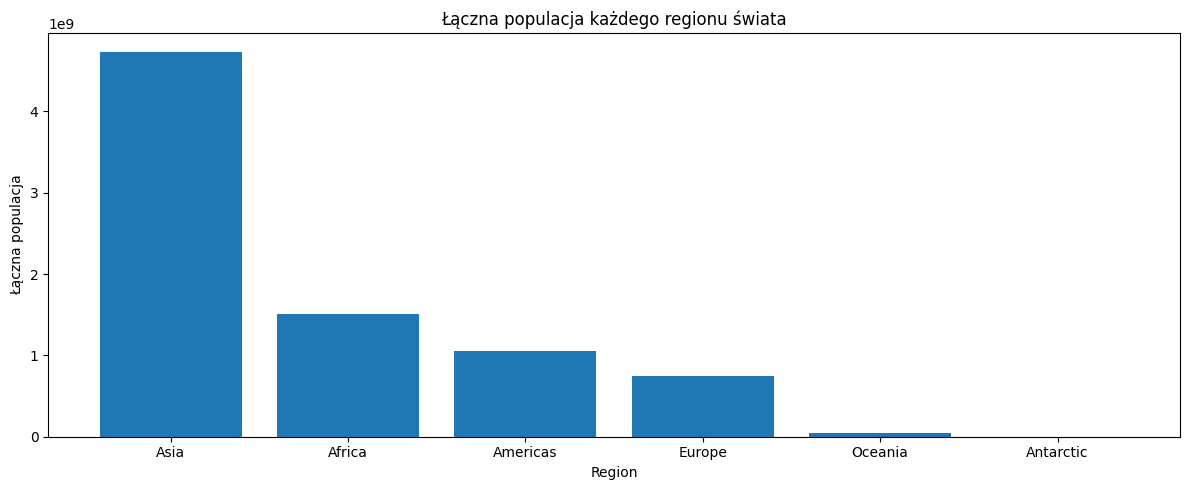

In [145]:
#wykres słupkowy
plt.figure(figsize=(12, 5))
plt.bar(df_populacja_per_region['region'], df_populacja_per_region['laczna_populacja'])

plt.xlabel("Region")
plt.ylabel("Łączna populacja")
plt.title("Łączna populacja każdego regionu świata")

plt.tight_layout()
plt.show()